In [ ]:
%pip install pandas matplotlib seaborn scikit-learn


^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [2]:
# Load the dataset (Make sure spam.csv is in the same folder!)
df = pd.read_csv('spam.csv')

# Display the first 5 rows
print("--- First 5 Rows of the Dataset ---")
print(df.head())

# Find the number of rows and columns
print(f"\nDataset Shape (Rows, Columns): {df.shape}")

# Check how many Ham and Spam messages are present
print("\n--- Distribution of Messages ---")
print(df['Category'].value_counts())


--- First 5 Rows of the Dataset ---
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

Dataset Shape (Rows, Columns): (5572, 2)

--- Distribution of Messages ---
Category
ham     4825
spam     747
Name: count, dtype: int64


C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4468\3849031810.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df, palette='Set2')


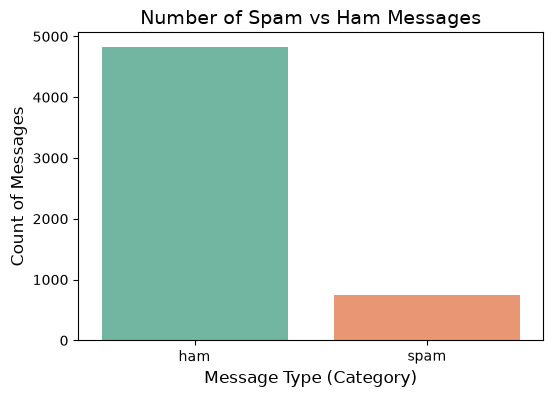


Question Answer: 'ham' (normal messages) is significantly more common in the dataset.


In [3]:
# Create a bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x='Category', data=df, palette='Set2')

# Add custom labels and title
plt.title('Number of Spam vs Ham Messages', fontsize=14)
plt.xlabel('Message Type (Category)', fontsize=12)
plt.ylabel('Count of Messages', fontsize=12)

# Show the plot directly inside the notebook
plt.show()

print("\nQuestion Answer: 'ham' (normal messages) is significantly more common in the dataset.")


In [4]:
# Convert text labels into numerical values
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

# Separate features (X) and target (y)
X = df['Message']
y = df['Category']

print("Data preparation complete! 'ham' is now 0 and 'spam' is now 1.")


Data preparation complete! 'ham' is now 0 and 'spam' is now 1.


In [5]:
# Divide the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} messages")
print(f"Testing data size: {X_test.shape[0]} messages")
print("\nQuestion Answer: We split the dataset into training and testing sets to evaluate our model's performance on unseen data. This ensures it actually learns patterns rather than just memorizing the answers.")


Training data size: 4457 messages
Testing data size: 1115 messages

Question Answer: We split the dataset into training and testing sets to evaluate our model's performance on unseen data. This ensures it actually learns patterns rather than just memorizing the answers.


In [7]:
# Initialize CountVectorizer and remove common English stopwords
vectorizer = CountVectorizer(stop_words='english')

# Convert text messages into numerical features
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)

print("Text messages successfully converted into numerical matrices!")
print("\nThink Answer: Machine Learning models are mathematical algorithms. They cannot read or understand text directly; they require numbers as input to calculate patterns and weights.")


Text messages successfully converted into numerical matrices!

Think Answer: Machine Learning models are mathematical algorithms. They cannot read or understand text directly; they require numbers as input to calculate patterns and weights.


In [8]:
# Initialize the Logistic Regression model
model = LogisticRegression()

# Train the model using our numerical training data
model.fit(X_train_transformed, y_train)

print("Model training complete! The model has learned to distinguish between Ham (0) and Spam (1).")


Model training complete! The model has learned to distinguish between Ham (0) and Spam (1).


In [9]:
# Predict labels for the test messages
predictions = model.predict(X_test_transformed)

print("Predictions successfully stored in the 'predictions' variable!")


Predictions successfully stored in the 'predictions' variable!


Model Accuracy: 98.39%



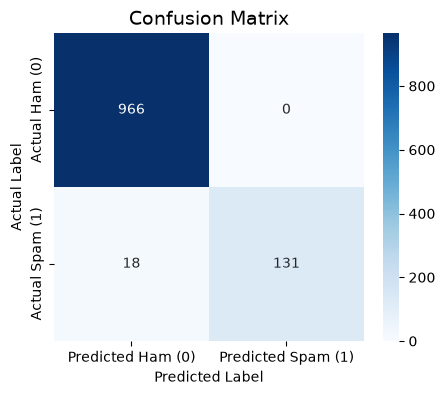


Question Answer: The model correctly classified a total of 1097 messages out of 1115 total test messages.


In [11]:
# Calculate accuracy score
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Generate the confusion matrix data
cm = confusion_matrix(y_test, predictions)

# Create a clean, visually scannable heatmap chart
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham (0)', 'Predicted Spam (1)'],
            yticklabels=['Actual Ham (0)', 'Actual Spam (1)'])

plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate total correct predictions dynamically
correct_predictions = cm[0, 0] + cm[1, 1]
print(f"\nQuestion Answer: The model correctly classified a total of {correct_predictions} messages out of {len(y_test)} total test messages.")


In [17]:
# Take a new SMS message from the user
user_sms = input("Enter a message to check for spam: ")

# Convert the new message using the same vectorizer vector structure
user_transformed = vectorizer.transform([user_sms])

# Ask the trained model to predict the category
user_prediction = model.predict(user_transformed)

# Display the final classification output
print(f"\nYour Message: \"{user_sms}\"")
if user_prediction[0] == 0:
    print("📩 HAM MESSAGE")
else:
    print("🚨 SPAM MESSAGE")



Your Message: "URGENT! Your account has been compromised. Click http://bit.ly immediately to reset your password and claim your bonus."
🚨 SPAM MESSAGE
